In [45]:
import keras
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) =\
keras.datasets.fashion_mnist.load_data()
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

In [46]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28,28,1)))
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu',
                              padding='same'))

In [47]:
model.add(keras.layers.MaxPooling2D(2))

In [48]:
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu',
                              padding='same'))
model.add(keras.layers.MaxPooling2D(2))

In [49]:
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))
model.add(keras.layers.Dense(10, activation='softmax'))

In [50]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

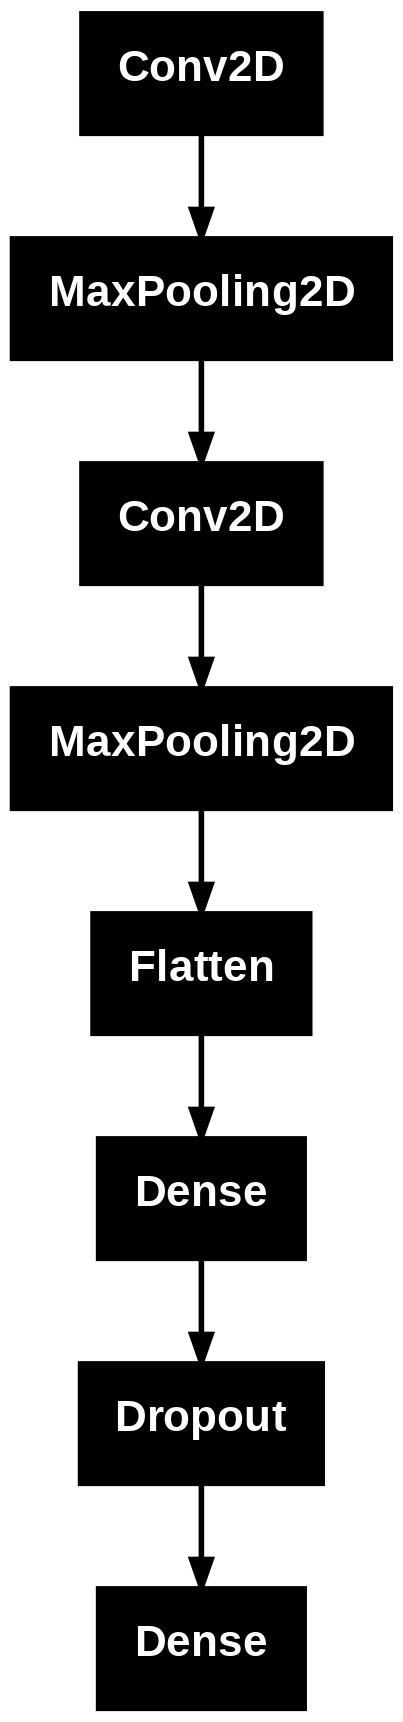

In [51]:
keras.utils.plot_model(model)

In [52]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                  restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 85s 56ms/step - accuracy: 0.7412 - loss: 0.7152 - val_accuracy: 0.8823 - val_loss: 0.3201
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 74s 49ms/step - accuracy: 0.8733 - loss: 0.3578 - val_accuracy: 0.9022 - val_loss: 0.2730
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.8924 - loss: 0.2959 - val_accuracy: 0.9014 - val_loss: 0.2611
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 59s 39ms/step - accuracy: 0.9043 - loss: 0.2615 - val_accuracy: 0.9109 - val_loss: 0.2411
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 58s 39ms/step - accuracy: 0.9160 - loss: 0.2301 - val_accuracy: 0.9168 - val_loss: 0.2290
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.9209 - loss: 0.2147 - val_accuracy: 0.9186 - val_loss: 0.2233
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 57s 38ms/step - accuracy: 0.9302 - loss: 0.1957 - val_accuracy: 0.9218 - val_loss: 0.2166
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 58s 39ms/step - accuracy: 0.9355 -

2절에서 만든 best-cnn-model.keras 파일 실행

In [53]:
import keras
model = keras.models.load_model('best-cnn-model.keras')

keras라이브러리 불러와서 저장해둔 'best-cnn-model' 불러오기

In [54]:
model.layers

[<Conv2D name=conv2d_5, built=True>,
 <MaxPooling2D name=max_pooling2d_4, built=True>,
 <Conv2D name=conv2d_6, built=True>,
 <MaxPooling2D name=max_pooling2d_5, built=True>,
 <Flatten name=flatten_2, built=True>,
 <Dense name=dense_6, built=True>,
 <Dropout name=dropout_2, built=True>,
 <Dense name=dense_7, built=True>]

model.layers는 Keras 모델 안에 포함된 **모든 레이어(layer)를 순서대로 담고 있는 리스트(list)

In [55]:
conv = model.layers[0]
print(conv.weights[0].shape, conv.weights[1].shape)

(3, 3, 1, 32) (32,)


첫 번째 Convolution 레이어의 가중치(weight) 모양(shape)을 출력

In [56]:
conv_weights = conv.weights[0].numpy()
print(conv_weights.mean(), conv_weights.std())

-0.022518171 0.23180908


conv.weights[0].numpy()

weights[0]은 Conv2D 레이어의 필터(커널) 가중치 텐서

.numpy()를 호출하여 NumPy 배열로 변환

conv_weights.mean()

모든 필터 가중치 값을 하나의 배열로 보고,

전체 평균값을 계산

conv_weights.std()

필터 가중치들의 표준편차(standard deviation) 를 계산합니다.

표준편차는
👉 가중치가 얼마나 퍼져 있는지,
👉 학습이 안정적으로 되었는지
판단

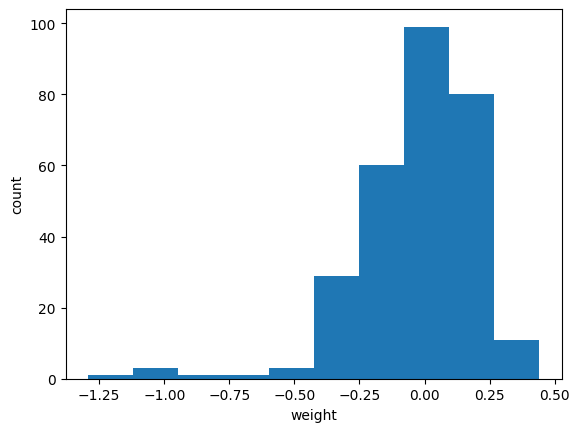

In [57]:
import matplotlib.pyplot as plt
plt.hist(conv_weights.reshape(-1,1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

conv_weights.reshape(-1, 1)

Conv 레이어의 필터 가중치(conv_weights)는 보통 다음처럼 4차원 구조
하지만 히스토그램은 1차원 배열만 받을 수 있으므로
모든 가중치를 일렬로 펼쳐서(flatten) 사용

plt.hist(...)

모든 필터 가중치의 분포를 히스토그램 형태로 시각화

x축: 각 가중치 값

y축: 해당 구간(bin)에 속하는 가중치 개수

plt.xlabel / plt.ylabel

x축(y축) 이름을 지정

x축: weight(가중치 값)

y축: count(해당 값이 몇 번 나오는지)

plt.show()

시각적으로 그림을 출력

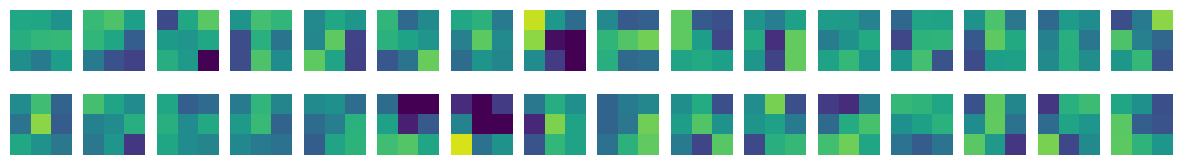

In [58]:
fig, axs = plt.subplots(2, 16, figsize=(15,2))
for i in range(2):
  for j in range(16):
    axs[i,j].imshow(conv_weights[:,:,0,i*16+j], vmin=-0.5, vmax=0.5)
    axs[i,j].axis('off')
plt.show()

plt.subplots(2, 16, figsize=(15,2))

2행 × 16열의 subplot 생성 → 총 32개의 필터 표시

figsize는 그림 전체 크기 조정

onv_weights[:,:,0,i*16+j]

conv_weights의 구조: (높이, 너비, 입력 채널, 필터 개수)

[:,:,0,...] → **첫 번째 입력 채널(R채널)**만 시각화

i*16+j → 0~31번째 32개 필터 선택

imshow(..., vmin=-0.5, vmax=0.5)

색상 범위를 -0.5 ~ 0.5로 고정 → 필터 값 시각적 비교 가능

흰색/검정색 대비로 필터의 특징 학습 정도 확인

axs[i,j].axis('off')

x, y축 눈금 제거 → 필터 모양만 깔끔하게 표시

plt.show()

모든 필터 이미지를 한 화면에 출력

In [59]:
no_training_model = keras.Sequential()
no_training_model.add(keras.layers.Input(shape=(28,28,1)))
no_training_model.add(keras.layers.Conv2D(32, kernel_size=3, activation=\
                                          'relu', padding='same'))


keras.Sequential():

순차적 레이어 쌓기 방식으로 모델 생성

keras.layers.Input(shape=(28,28,1)):

입력 이미지의 형태(shape) 지정
높이 28, 너비 28, 채널 1(흑백 이미지)
모델에 들어올 데이터 크기를 명시

keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'):

합성곱 레이어 정의

주요 파라미터:

32 → 필터(커널) 개수

kernel_size=3 → 3×3 필터
activation='relu' → 비선형 활성화 함수 ReLU
padding='same' → 입력과 동일한 크기로 출력 유지

In [60]:
no_training_conv = no_training_model.layers[0]
print(no_training_conv.weights[0].shape)

(3, 3, 1, 32)


no_training_model.layers[0]:

모델의 **첫 번째 레이어(Conv2D)**를 가져옴
학습 전이므로 가중치는 초기화 상태

no_training_conv.weights[0]

Conv 레이어의 필터(커널) 가중치
형태(shape)는 (커널 높이, 커널 너비, 입력 채널, 필터 개수)

In [61]:
no_training_weights = no_training_conv.weights[0].numpy()
print(no_training_weights.mean(), no_training_weights.std())

-0.008501108 0.0836723


no_training_conv.weights[0].numpy():

첫 번째 Conv 레이어의 필터(커널) 가중치를 NumPy 배열로 변환
학습 전이므로 랜덤 초기화 상태값

no_training_weights.mean():

모든 필터 가중치의 평균값 계산
초기화된 가중치는 대부분 0 근처

no_training_weights.std():

모든 필터 가중치의 표준편차 계산
초기화 시 사용된 분포 범위 확인 가능

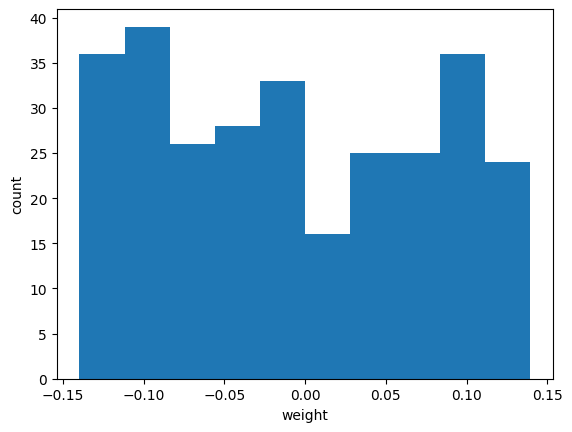

In [62]:
plt.hist(no_training_weights.reshape(-1,1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

no_training_weights.reshape(-1,1):

Conv 필터 가중치 배열은 (커널 높이, 커널 너비, 입력 채널, 필터 개수) 형태의 4차원 배열
히스토그램을 그리기 위해 1차원으로 펼치기(flatten)

plt.hist(...):

가중치 값 분포를 히스토그램으로 시각화
x축: 가중치 값
y축: 해당 값이 나타난 횟수(count)

plt.xlabel, plt.ylabel:
x축: weight (가중치 값)
y축: count (값 개수)

plt.show()
히스토그램 출력

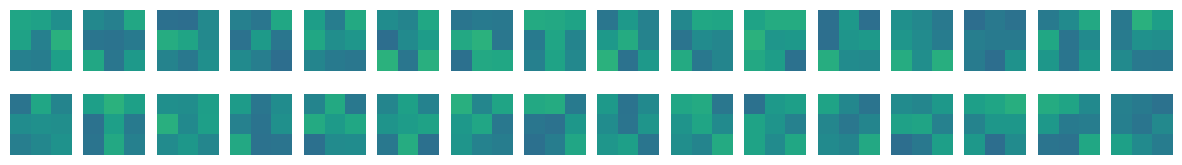

In [63]:
fig, axs = plt.subplots(2, 16, figsize=(15,2))
for i in range(2):
  for j in range(16):
    axs[i,j].imshow(no_training_weights[:,:,0,i*16+j], vmin=-0.5,
                    vmax=0.5)
    axs[i,j].axis('off')
plt.show()

plt.subplots(2, 16, figsize=(15,2)):

2행 × 16열 subplot 생성 → 총 32개의 필터 표시
figsize로 그림 전체 크기 조정

no_training_weights[:,:,0,i*16+j]:

no_training_weights의 구조: (높이, 너비, 입력 채널, 필터 개수)
[:,:,0,...] → 첫 번째 입력 채널만 시각화
i*16+j → 0~31번째 필터 선택

imshow(..., vmin=-0.5, vmax=0.5):

색상 범위 고정 → 필터 값 크기와 방향 확인 가능
음수/양수 값 대비로 필터 초기 상태 시각화

axs[i,j].axis('off'):

x, y축 눈금 제거 → 필터 모양만 깔끔하게 표시

plt.show():

모든 필터를 한 화면에 출력

In [64]:
inputs = keras.Input(shape=(784,))
dense1 = keras.layers.Dense(100, activation='relu')
dense2 = keras.layers.Dense(10, activation='softmax')

keras.Input(shape=(784,)):

입력 데이터의 형태(shape) 정의
여기서는 28×28 이미지를 1차원으로 펼쳐 784개의 입력 노드 사용

keras.layers.Dense(100, activation='relu'):

첫 번째 완전연결 레이어 정의
100개의 뉴런, ReLU 활성화 함수 사용
역할: 입력 특징을 선형 변환 + 비선형 변환하여 다음 층으로 전달

keras.layers.Dense(10, activation='softmax'):

출력 레이어 정의
10개의 뉴런, Softmax 활성화 함수 사용
역할: 10개의 클래스 확률 출력 (분류 문제)

In [65]:
hidden = dense1(inputs)

입력 데이터를 첫 번째 Dense 레이어에 통과시켜 100차원의 특징 벡터(hidden)를 생성

In [66]:
outputs = dense2(hidden)

첫 번째 Dense 레이어의 특징 벡터(hidden)를 두 번째 Dense 레이어를 통해 10개 클래스 확률(outputs)로 변환

In [67]:
func_model = keras.Model(inputs, outputs)

Functional API를 사용해 입력과 출력을 연결함으로써, 784차원 입력을 100차원 hidden을 거쳐 10개 클래스 확률로 출력하는 모델을 완성

In [68]:
print(model.inputs)

[<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=input_layer_5>]


model.inputs:

Keras 모델에서 입력 레이어(텐서) 정보를 반환
형태(shape), 데이터 타입(dtype) 등 확인 가능




In [69]:
conv_acti = keras.Model(model.inputs[0], model.layers[0].output)

keras.Model(inputs, outputs)

Functional API를 사용해 새로운 모델 생성

inputs → 원래 모델의 입력

outputs → 관심 있는 첫 번째 Conv 레이어 출력

결과: 입력 이미지를 넣으면 Conv 레이어 활성화 값만 출력하는 모델

model.layers[0].output:

model.layers[0] → 첫 번째 Conv 레이어
.output → 해당 레이어의 출력 텐서 (활성화 값, feature map)

즉, Functional API를 사용해 첫 번째 Conv 레이어 출력만 추출하는 모델을 만들어, 입력 이미지가 이 레이어에서 어떻게 변환되는지 확인가능

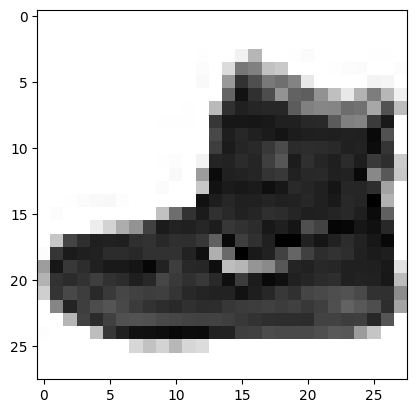

In [70]:
(train_input, train_target), (test_input, test_target) =\
keras.datasets.fashion_mnist.load_data()
plt.imshow(train_input[0], cmap='gray_r')
plt.show()

keras.datasets.fashion_mnist.load_data():

Fashion MNIST 데이터셋 불러오기

구성:

train_input → 학습 이미지 (28×28 흑백)
train_target → 학습 레이블 (0~9 클래스)
test_input, test_target → 테스트용 데이터

plt.imshow(train_input[0], cmap='gray_r'):

첫 번째 학습 이미지 시각화
cmap='gray_r' → 흑백 반전 색상으로 표시
흰색 배경, 검은색 옷 아이템

plt.show():
이미지 출력

In [71]:
ankle_boot = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0
feature_maps = conv_acti.predict(ankle_boot)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


train_input[0:1].reshape(-1, 28, 28, 1):

첫 번째 이미지 선택 (0:1 → 1장의 배치)
4차원 텐서로 변환: (배치 크기, 높이, 너비, 채널)
CNN 입력 형식에 맞춤
흑백 채널 추가 → (1, 28, 28, 1)

/ 255.0:

픽셀 값을 0~1 범위로 정규화
신경망 학습 시 학습 안정성 향상

conv_acti.predict(ankle_boot):

첫 번째 Conv 레이어 활성화 값(feature map) 추출
출력: (1, 28, 28, 32)
32개의 필터(feature map)별로 28×28 활성화 값 생성


In [72]:
print(feature_maps.shape)

(1, 28, 28, 32)


feature_maps.shape

출력 형태(shape)를 확인

예시: (1, 28, 28, 32)

차원	의미
1	배치 크기 (한 장의 이미지)
28	feature map 높이
28	feature map 너비
32	Conv 레이어 필터 개수 → 각 필터별 activation map

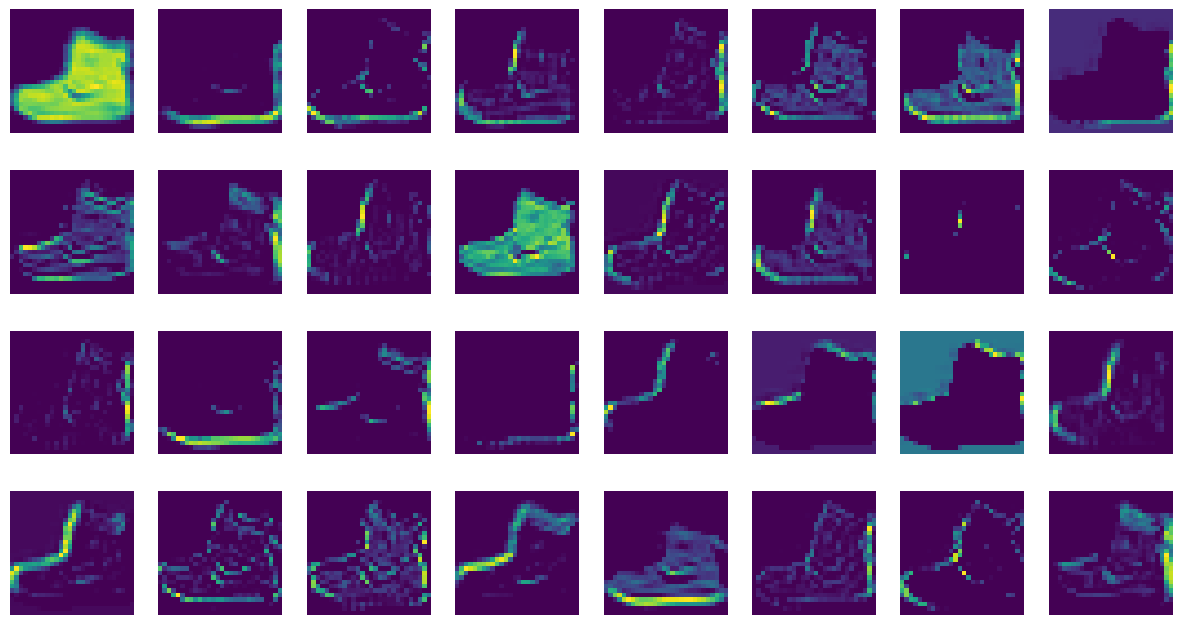

In [73]:
fig, axs = plt.subplots(4, 8, figsize=(15,8))
for i in range(4):
  for j in range(8):
    axs[i,j].imshow(feature_maps[0,:,:,i*8+j])
    axs[i,j].axis('off')
plt.show()

lt.subplots(4, 8, figsize=(15,8)):

4행 × 8열 subplot 생성 → 총 32개의 feature map 표시
figsize → 그림 전체 크기 설정

feature_maps[0,:,:,i*8+j]:

0번째 이미지의 i*8+j 번째 feature map 선택
shape (28, 28) → Conv 필터가 감지한 활성화 값

axs[i,j].imshow(...):

feature map을 이미지로 시각화
밝기/어둠 → 필터가 감지한 특징의 강도

axs[i,j].axis('off'):

x, y축 눈금 제거 → feature map만 깔끔하게 표시

plt.show():

모든 feature map 출력

In [74]:
conv2_acti = keras.Model(model.inputs[0], model.layers[2].output)

keras.Model(inputs, outputs):

Functional API 사용 → 새로운 모델 생성
inputs → 원래 모델의 입력
outputs → 관심 있는 두 번째 Conv 레이어 출력
결과: 입력 이미지를 넣으면 두 번째 Conv 레이어 feature map만 출력

model.layers[2].output:
model.layers[2] → 두 번째 Conv 레이어
.output → 해당 레이어의 출력 텐서 (feature map)

Functional API를 사용해 두 번째 Conv 레이어 출력만 추출하는 모델을 만들어, 입력 이미지가 심화된 특징으로 변환되는 과정을 확인

In [75]:
feature_maps = conv2_acti.predict(ankle_boot)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


conv2_acti.predict(ankle_boot):

ankle_boot → 전처리된 첫 번째 이미지 (1, 28, 28, 1)
두 번째 Conv 레이어 출력만 추출

출력: (1, 28, , 64):
64개의 필터(feature map)별로 28×28 활성화 값 생성

의미:

첫 번째 Conv 레이어보다 더 심화된 특징(feature) 추출
초기 레이어 → 엣지, 선
두 번째 레이어 → 모서리, 패턴, 복합 구조 감지

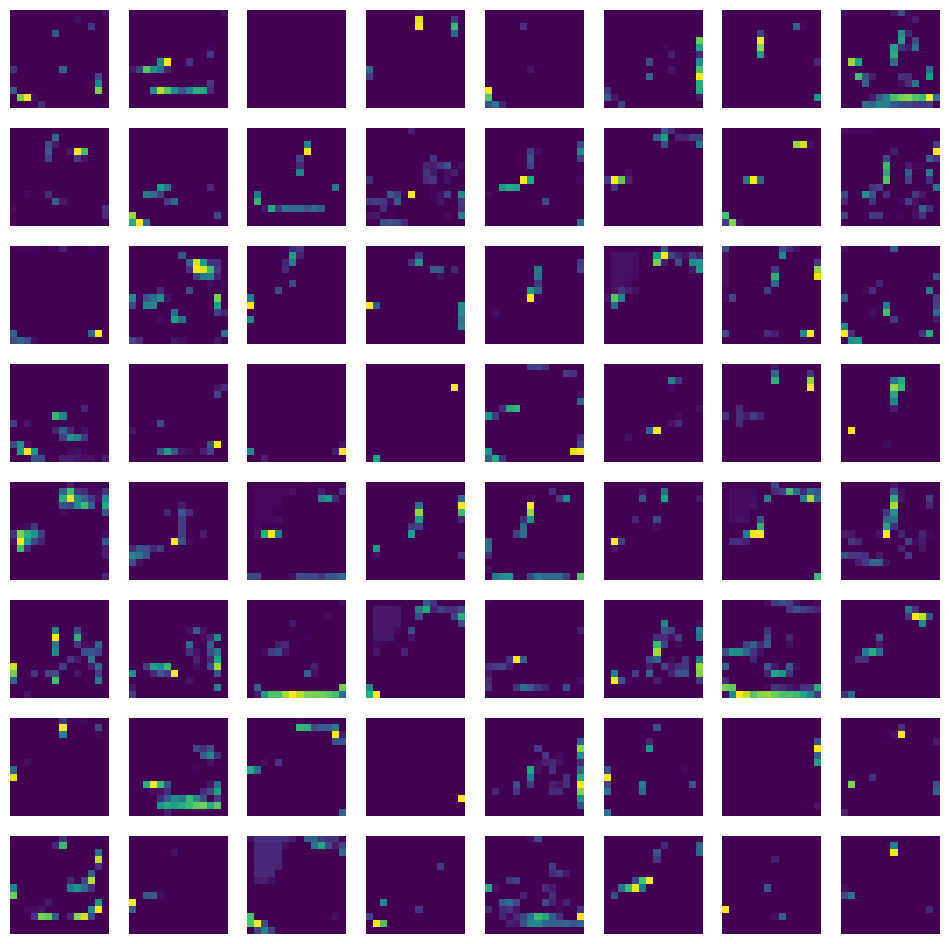

In [76]:
fig, axs = plt.subplots(8,8, figsize=(12,12))
for i in range(8):
  for j in range(8):
    axs[i,j].imshow(feature_maps[0,:,:,i*8+j])
    axs[i,j].axis('off')
plt.show()